TELCO ANALYSIS MACHINE LEARNING

In this project, the dataset named Telco Customer Churn from Kaggle was used. Each row represents a customer, each column contains the customer's attributes.

a. This dataset contains 21 columns (variables) and 7043 rows (customers) with information such as customerID, gender, Phone Service, and Internet Service.

b. Table 1 shows the data types of the variables with 17 categorical and 4 numerical data.

1. IMPORT LIBRARY

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

2. LOAD DATASET

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Early Assumption:

1. Customers with monthly contracts are at higher risk of churn.

2. Customers with high costs are more likely to churn.

3. New customers churn more frequently.

3. Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Change Data Type For Column Total Charges Because Still Object Not Numeric And Using errors=coerce. It will replace all non-numeric values with NaN.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'].fillna(0, inplace=True)

/tmp/ipython-input-171940771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

4. EDA

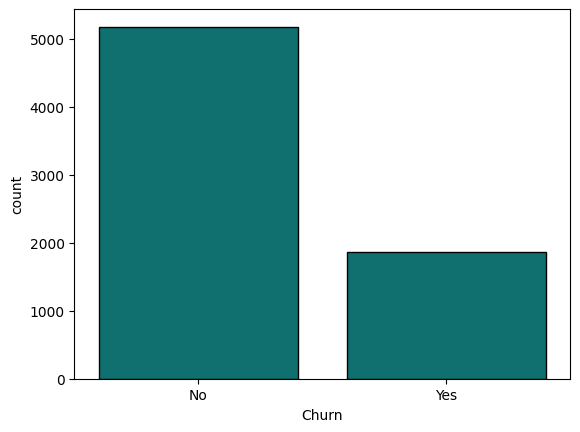

In [ ]:
sns.countplot(x='Churn', data=df, color='Teal', edgecolor='black')
plt.show()

Unbalanced dataset, more customers do not churn.

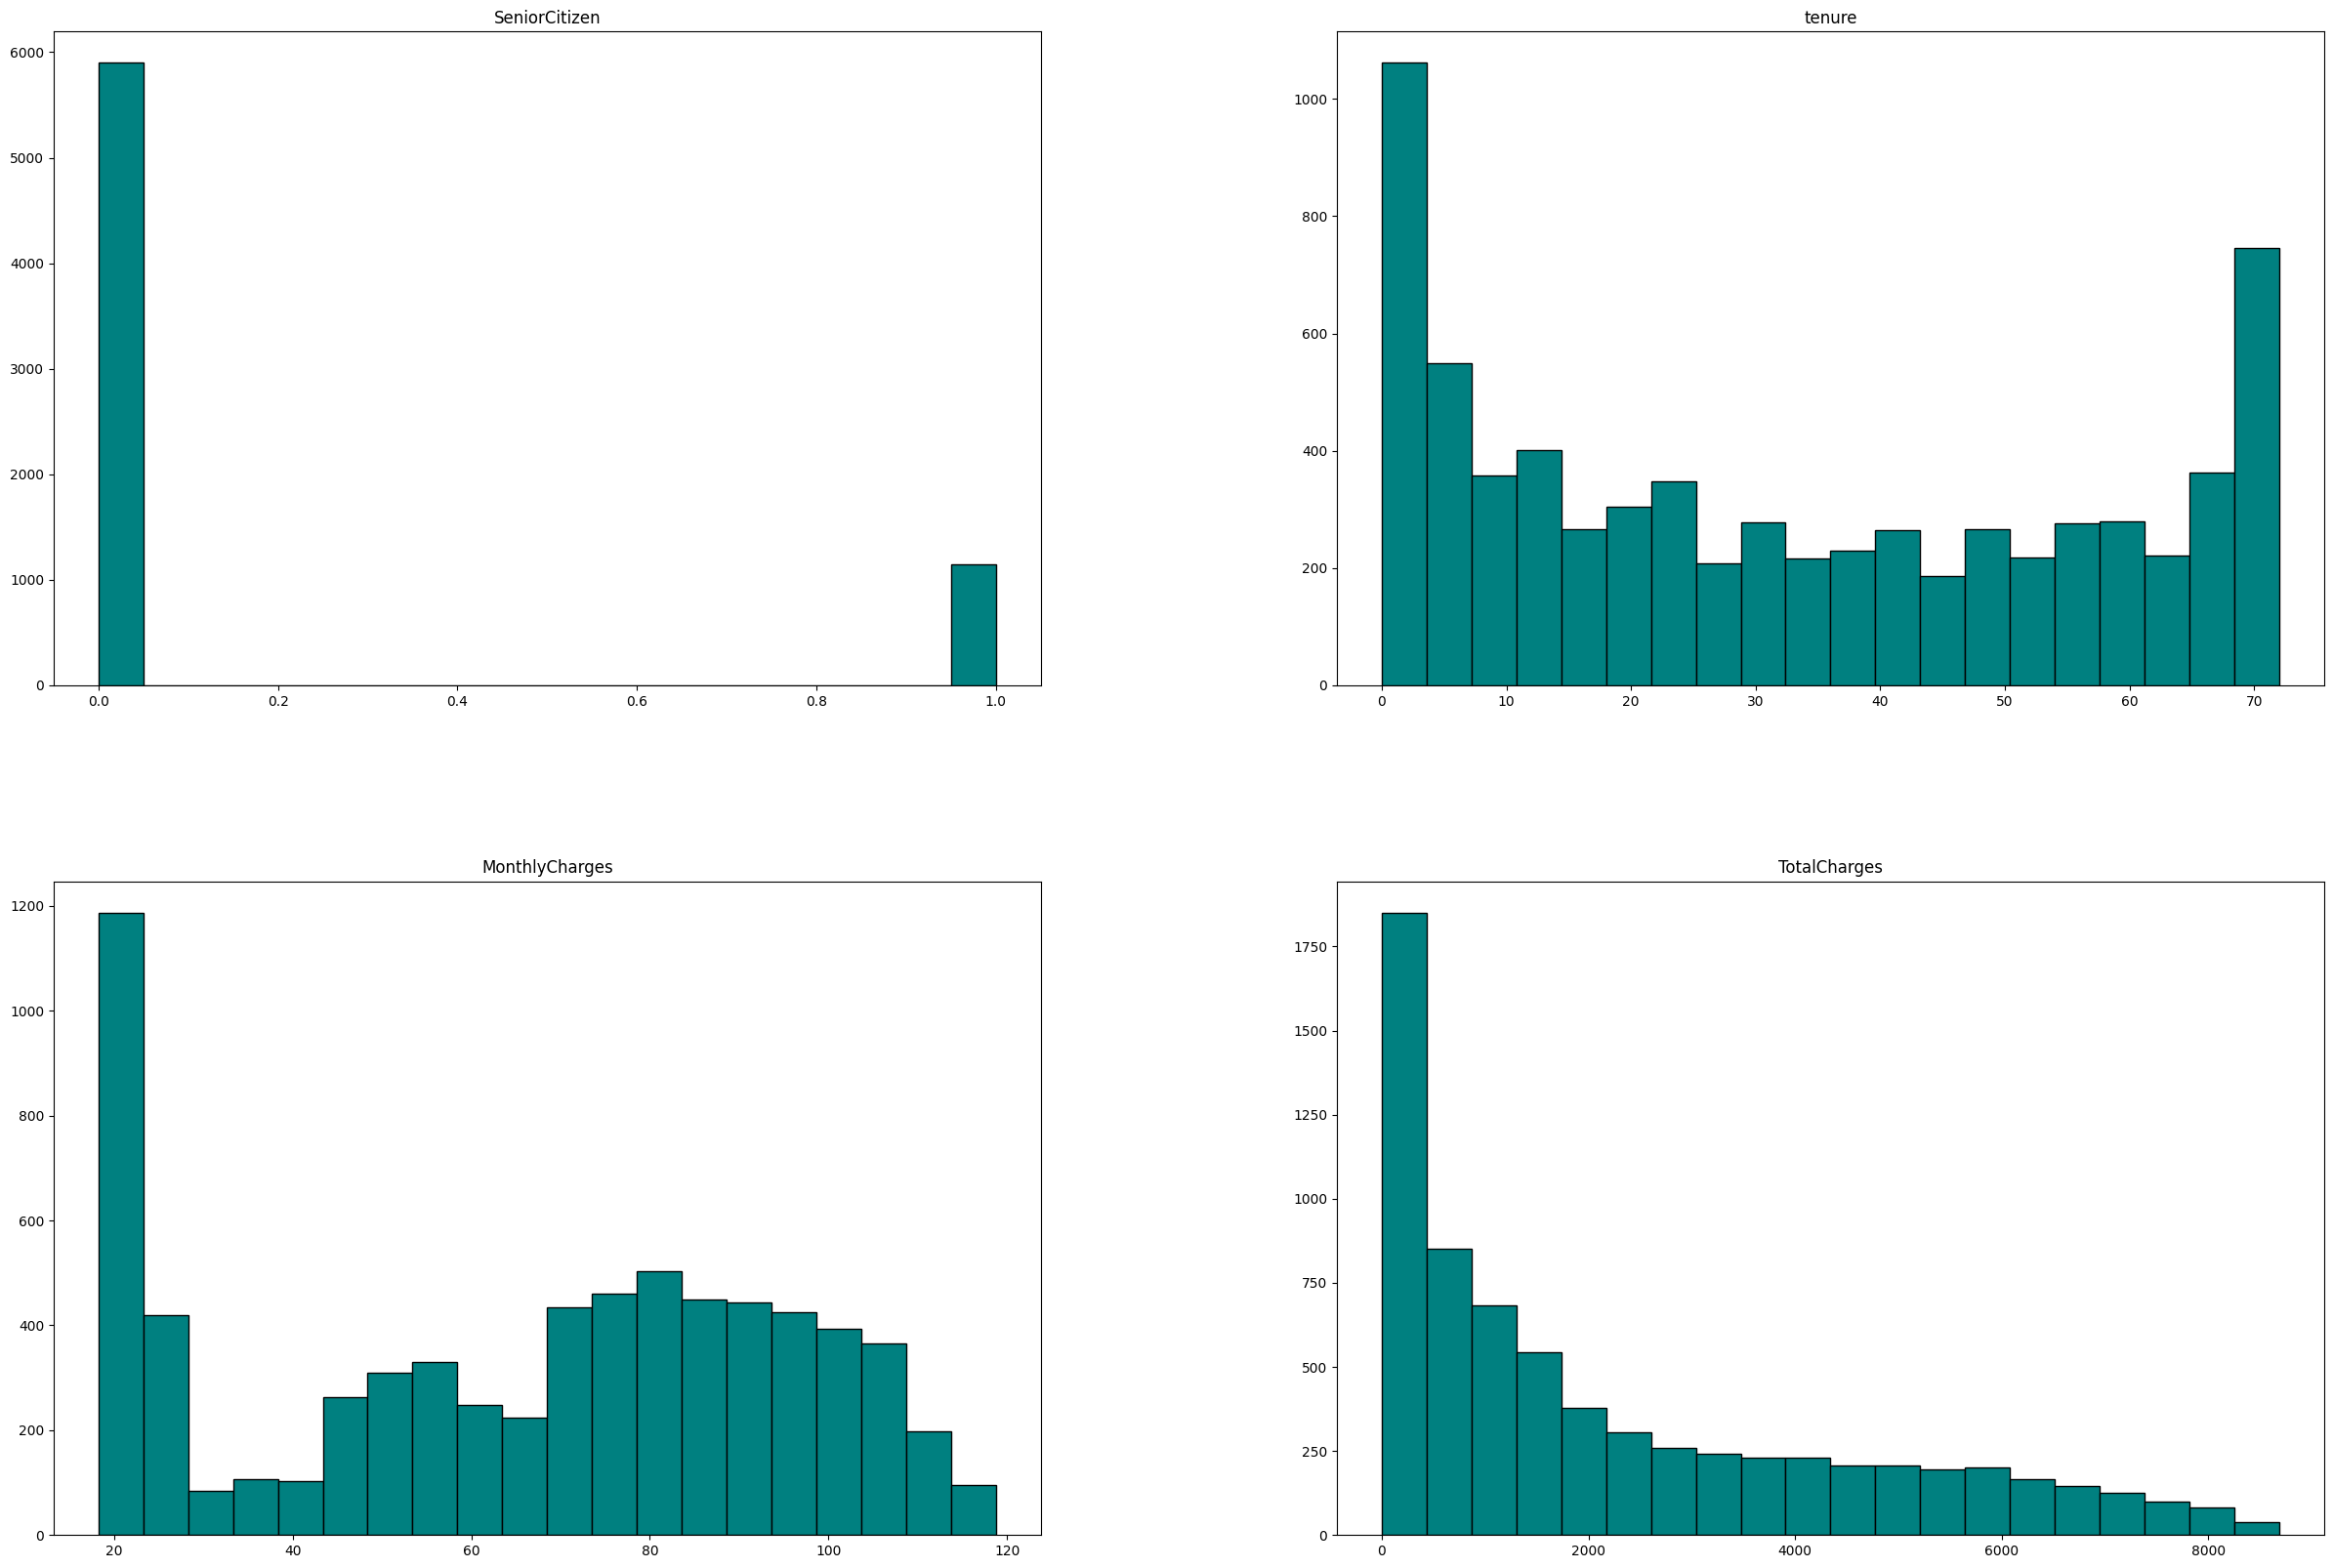

In [ ]:
number_bins = 20
df.hist(bins=number_bins, figsize=(30,20), grid=False, color='Teal', edgecolor='black')
plt.show()

In [ ]:
df['Churn'] = df['Churn'].map({'No': 0, "Yes": 1})

In [ ]:
def churn_rate_plot(column, color='steelblue'):
  rate = (df.groupby(column)['Churn'].
          mean().
          sort_values(ascending=False))

  plt.figure(figsize=(12,6))
  rate.plot(kind='bar', color=color)

  plt.ylabel('Churn Rate')
  plt.xlabel(column)
  plt.xticks(rotation = 0)
  plt.title(f'Churn Rate by {column}')

  plt.grid(False)
  plt.tight_layout()
  plt.show()

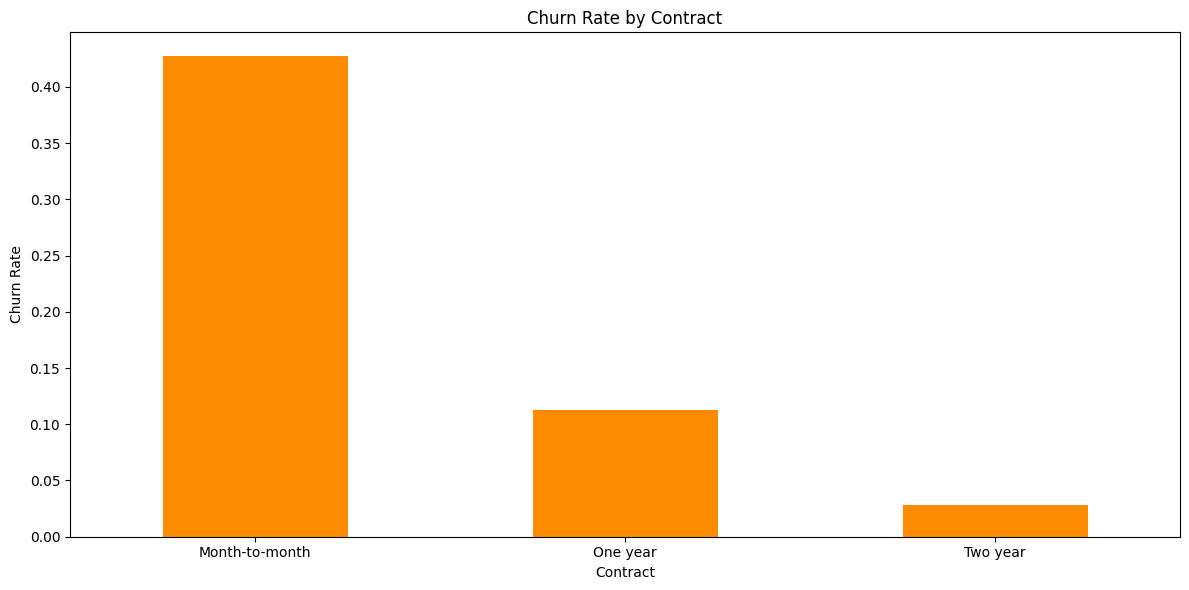

In [ ]:
churn_rate_plot('Contract', color='darkorange')

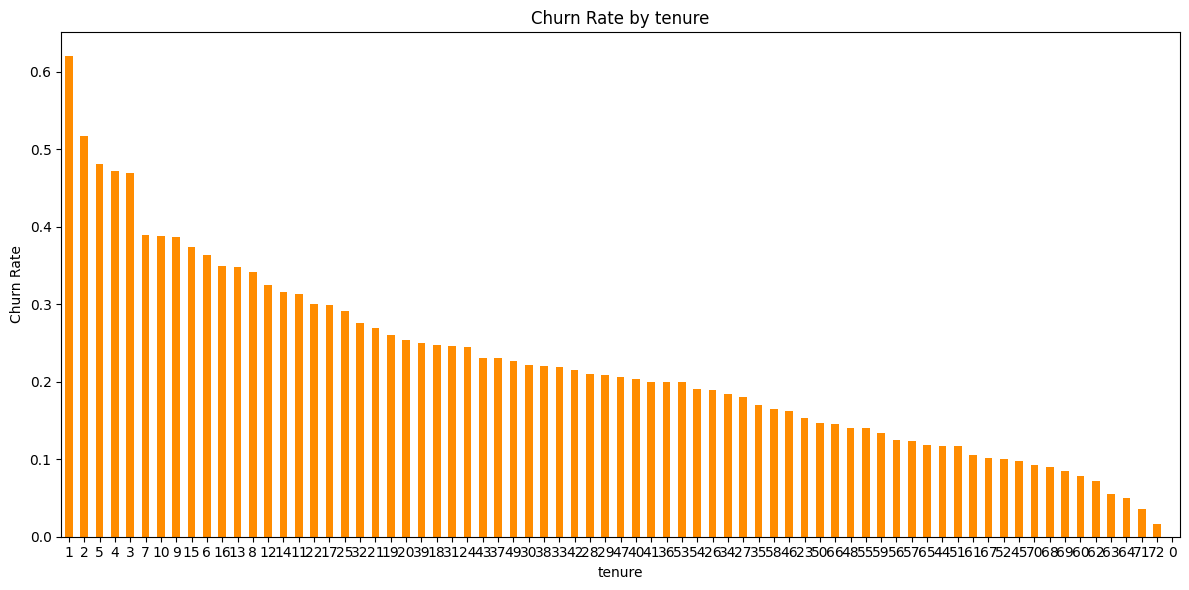

In [ ]:
churn_rate_plot('tenure', color='darkorange')

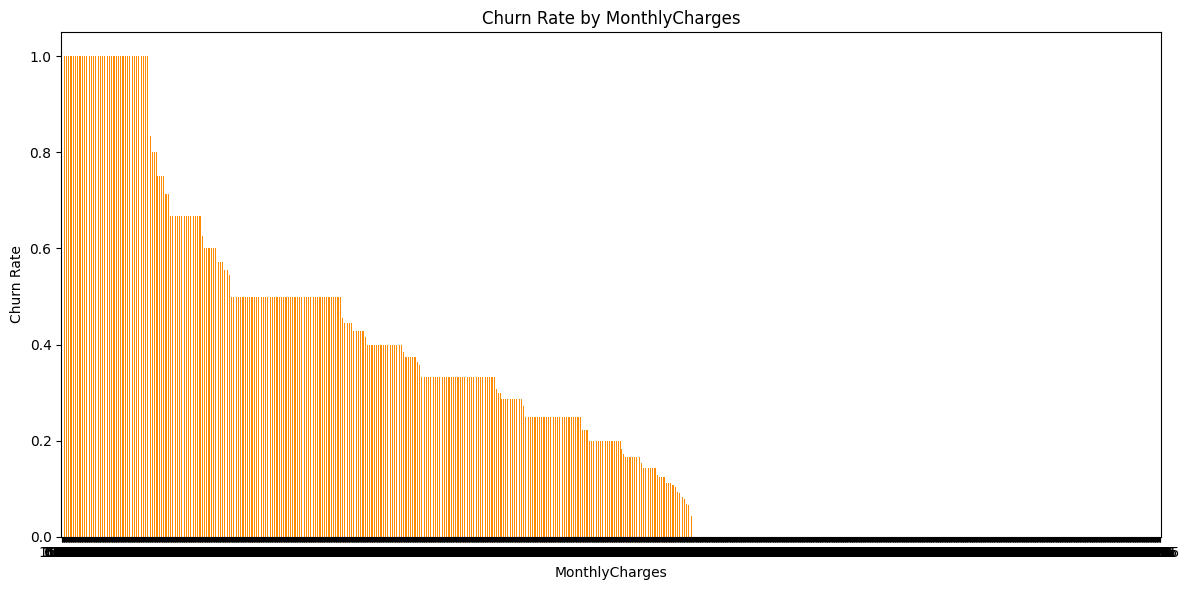

In [ ]:
churn_rate_plot('MonthlyCharges', color='darkorange')

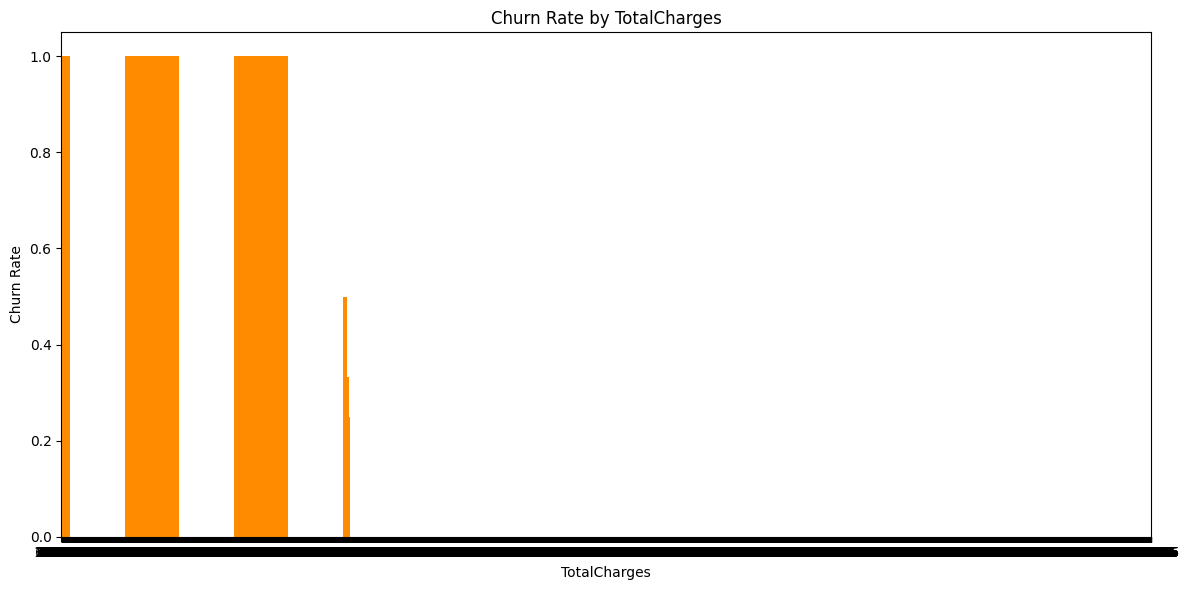

In [ ]:
churn_rate_plot('TotalCharges', color='darkorange')

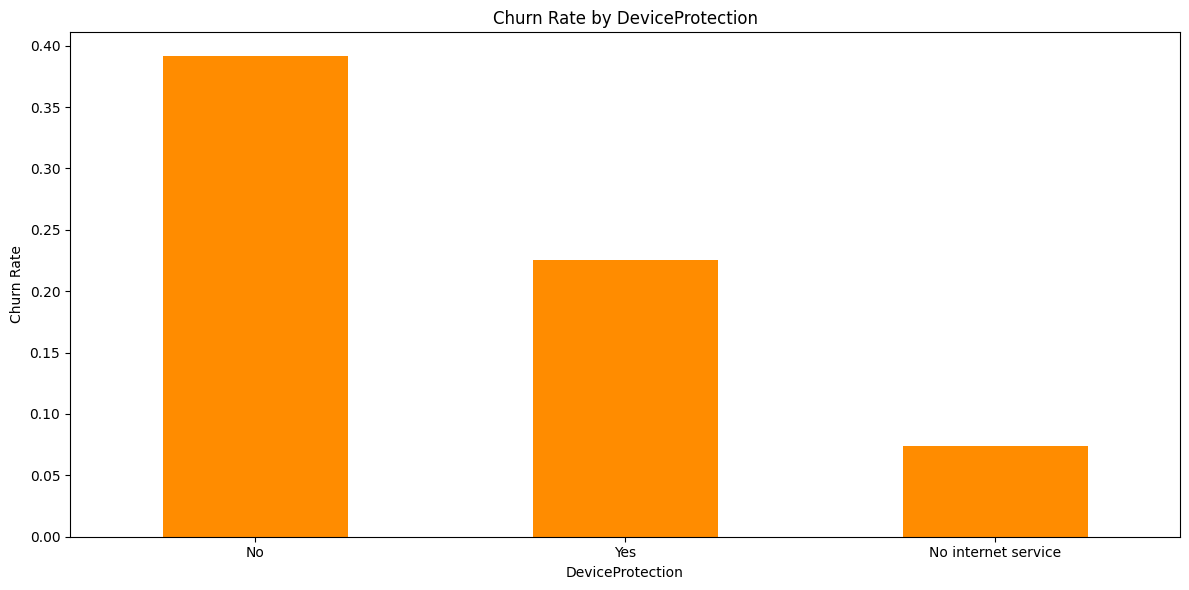

In [ ]:
churn_rate_plot('DeviceProtection', color='darkorange')

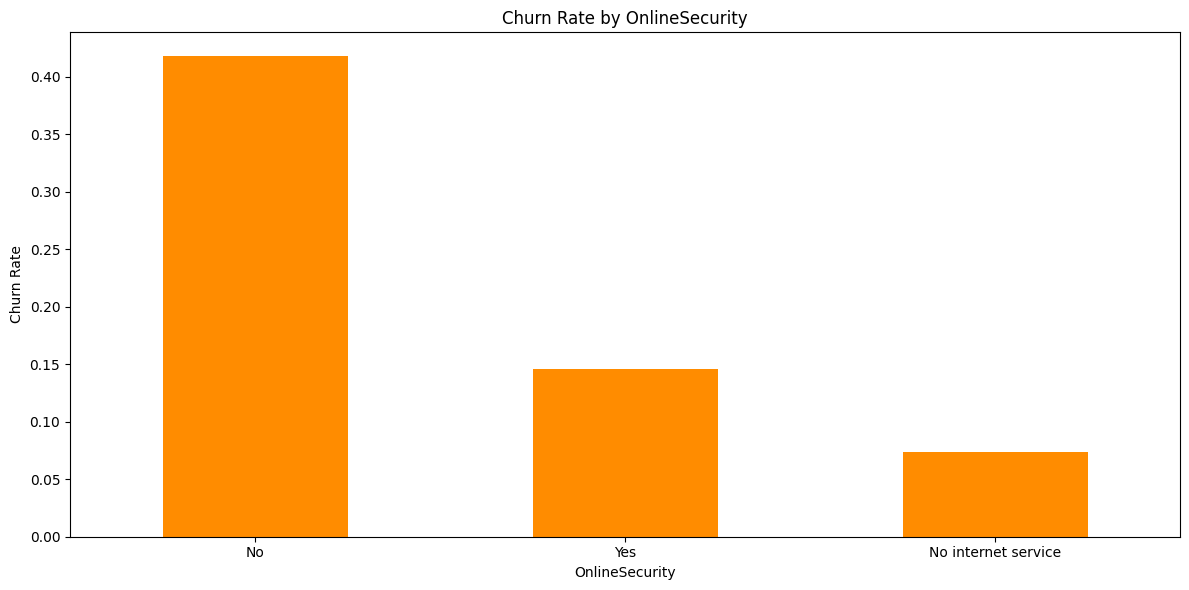

In [ ]:
churn_rate_plot('OnlineSecurity', color='darkorange')

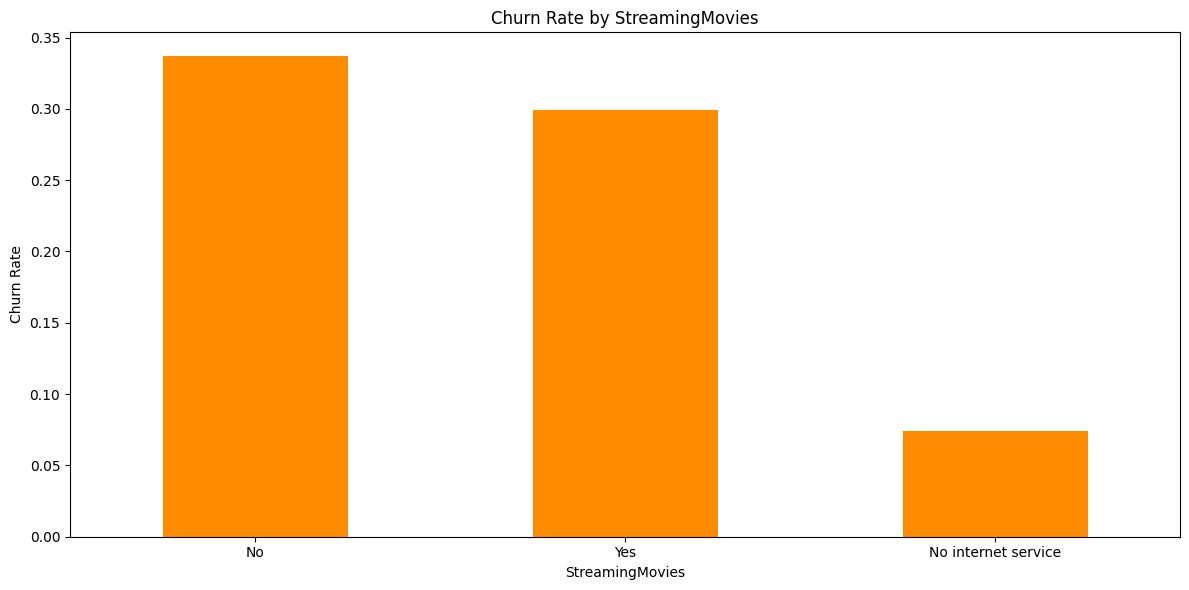

In [ ]:
churn_rate_plot('StreamingMovies', color='darkorange')

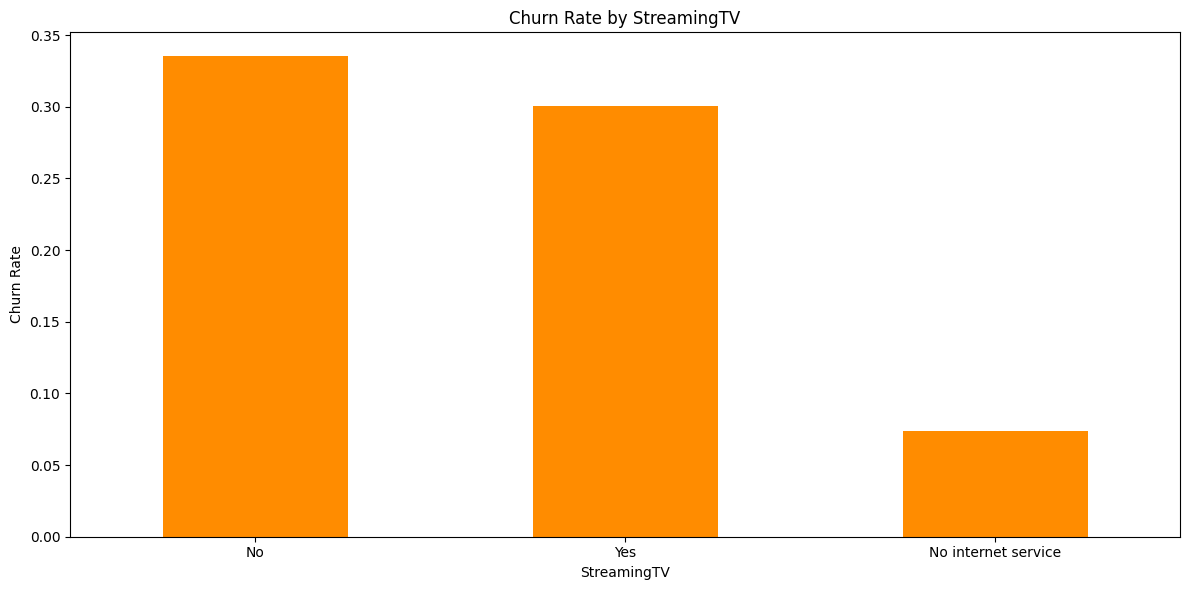

In [ ]:
churn_rate_plot('StreamingTV', color='darkorange')

Correlation Numeric

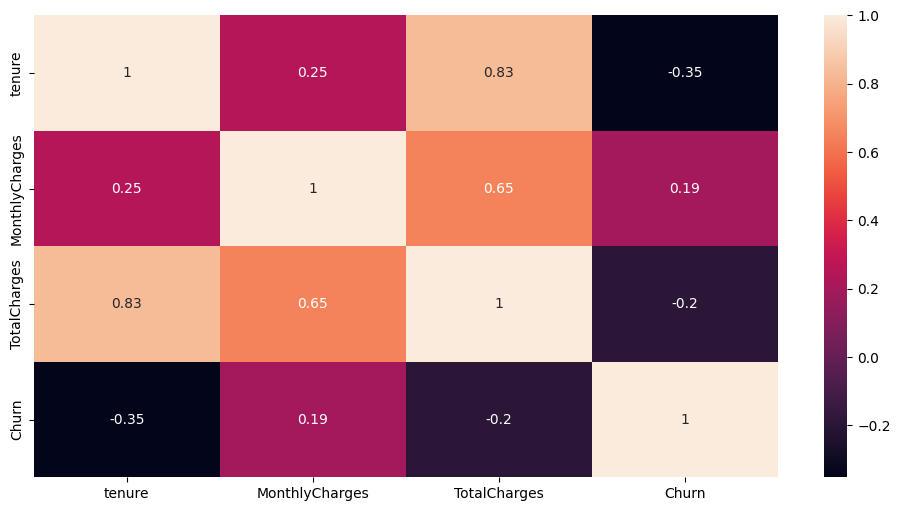

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(), annot=True)
plt.show()

5. Machine Learning

Logistic Regression Part

In [ ]:
x = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

In [ ]:
x = pd.get_dummies(x, drop_first=True)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
logistic_Regress = LogisticRegression(max_iter=1000)
logistic_Regress.fit(x_train_scaled, y_train)
y_pred_logistic_regress = logistic_Regress.predict(x_test_scaled)
print(classification_report(y_test, y_pred_logistic_regress))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Random Forest Classification

In [ ]:
random_forest = RandomForestClassifier(random_state=42,
                                       n_estimators=200,
                                       max_depth=10,
                                       class_weight='balanced')
random_forest.fit(x_train, y_train)
y_pred_random_forest = random_forest.predict(x_test)
print(classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



Visualization

In [ ]:
from sklearn.metrics import confusion_matrix

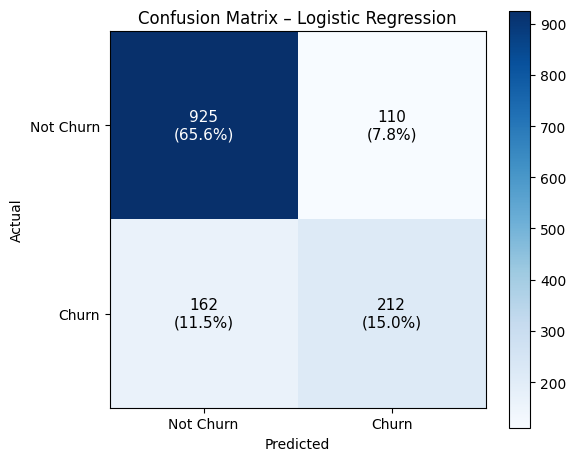

In [ ]:
cm = confusion_matrix(y_test, y_pred_logistic_regress)
cm_percent = cm / cm.sum() * 100

labels = ["Not Churn", "Churn"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        text = f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)"
        plt.text(j, i, text,
                 ha="center", va="center",
                 color=color, fontsize=11)

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")

plt.colorbar()
plt.tight_layout()
plt.show()

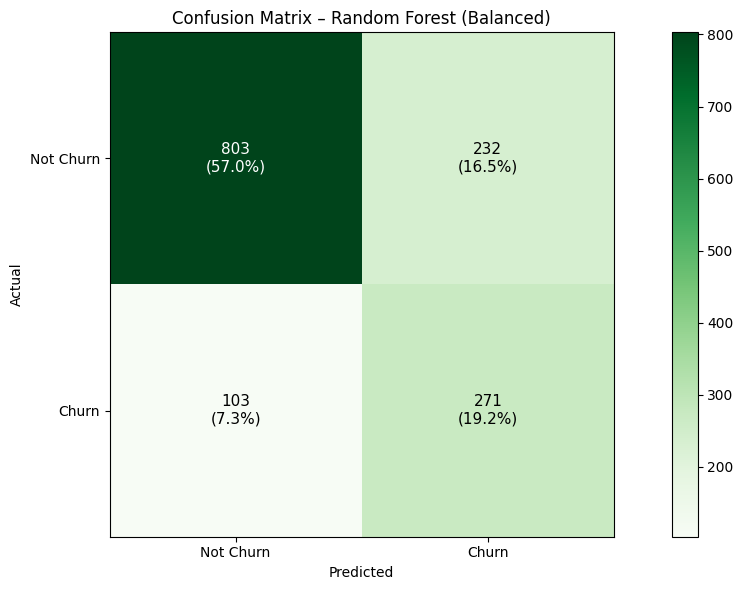

In [ ]:
# Confusion matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_random_forest)
cm_rf_percent = cm_rf / cm_rf.sum() * 100

labels = ["Not Churn", "Churn"]

plt.figure(figsize=(12, 6))
plt.imshow(cm_rf, cmap="Greens")  # beda warna agar mudah dibandingkan

threshold = cm_rf.max() / 2

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        color = "white" if cm_rf[i, j] > threshold else "black"
        text = f"{cm_rf[i, j]}\n({cm_rf_percent[i, j]:.1f}%)"
        plt.text(j, i, text,
                 ha="center", va="center",
                 color=color, fontsize=11)

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest (Balanced)")

plt.colorbar()
plt.tight_layout()
plt.show()

ROC - AUC

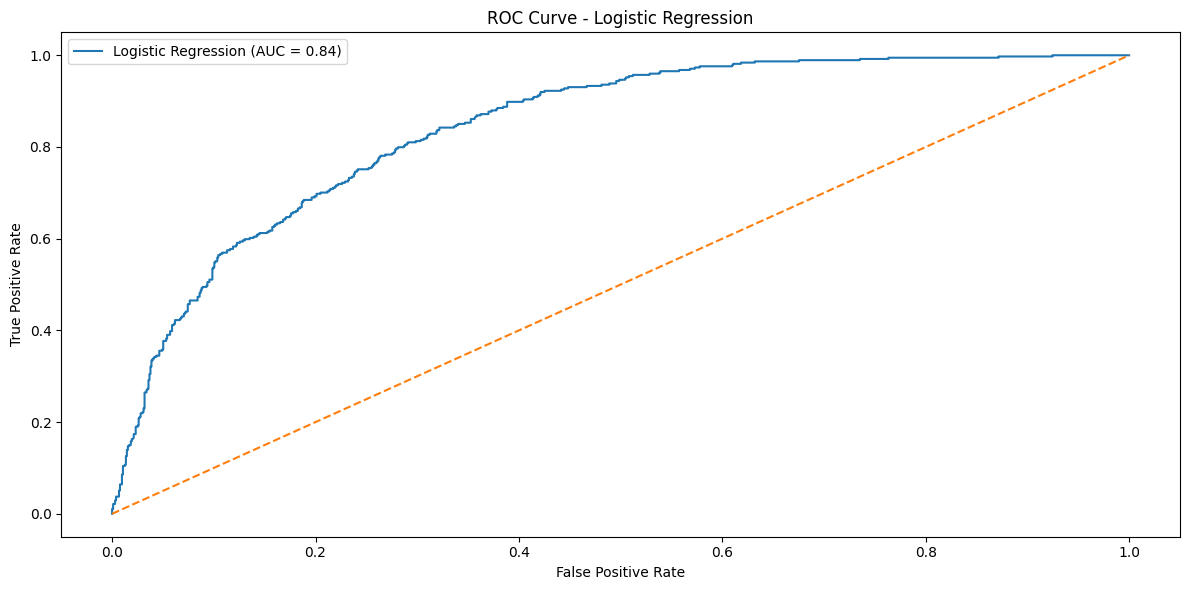

In [ ]:

from sklearn.metrics import roc_curve, auc

# 1. Ambil probabilitas CHURN (bukan prediksi 0/1)
probabilitas_churn_logistic = logistic_Regress.predict_proba(x_test_scaled)[:, 1]

# 2. Hitung komponen ROC
false_positive_rate, true_positive_rate, threshold = roc_curve(
    y_test,
    probabilitas_churn_logistic
)

# 3. Hitung AUC
nilai_auc_logistic = auc(false_positive_rate, true_positive_rate)

# 4. Gambar kurva
plt.figure(figsize=(12, 6))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Logistic Regression (AUC = {nilai_auc_logistic:.2f})"
)

# garis tebakan acak
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

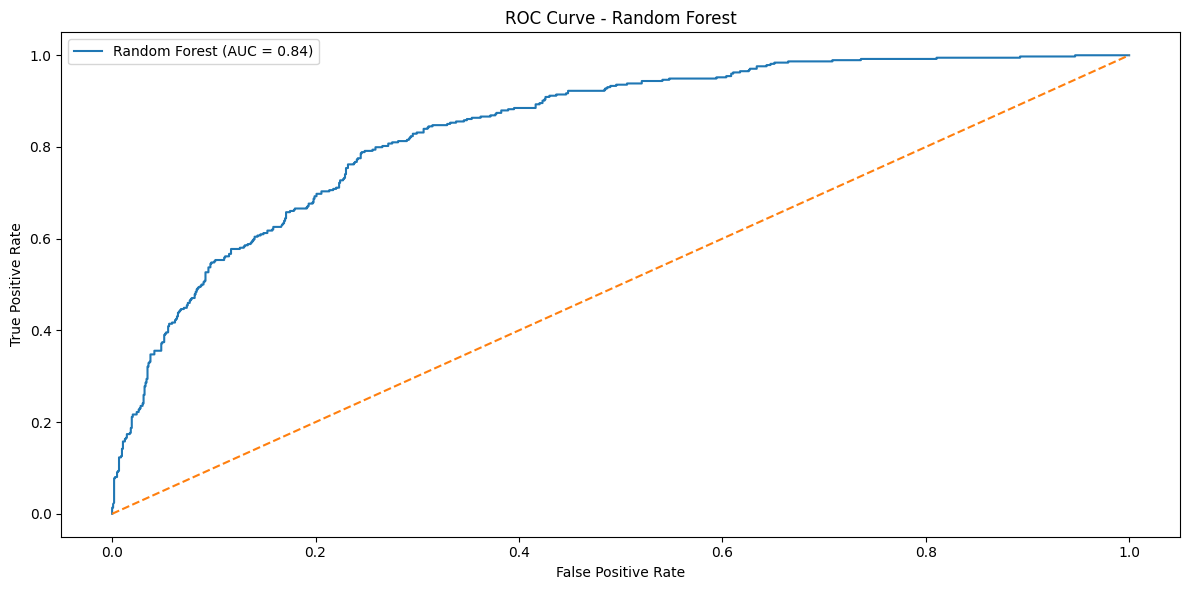

In [ ]:
probabilitas_churn_rf = random_forest.predict_proba(x_test)[:, 1]

fpr_rf, tpr_rf, threshold_rf = roc_curve(
    y_test,
    probabilitas_churn_rf
)

auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(12, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

6. Export To Tableau

In [ ]:
Output_Rf = x_test.copy()
Output_Rf['Actual_Churn'] = y_test.values
Output_Rf['Predicted_Churn'] = y_pred_random_forest
Output_Rf['Probability_Churn'] = random_forest.predict_proba(x_test)[:,1]
Output_Rf.to_csv('churn_prediction_random_forest.csv', index=False)

In [ ]:
Output_Lr = x_test.copy()

Output_Lr['Actual_Churn'] = y_test.values
Output_Lr['Predicted_Churn'] = y_pred_logistic_regress
Output_Lr['Churn_Probability'] = logistic_Regress.predict_proba(x_test_scaled)[:,1]

Output_Lr.to_csv('churn_prediction_logistic_regression.csv', index=False)

In [ ]:
df2 = pd.read_csv('/content/churn_prediction_logistic_regression.csv')

In [ ]:
df2.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Predicted_Churn,Churn_Probability
0,0,72,114.05,8468.20,True,True,True,True,False,True,...,True,False,True,True,True,False,False,0,0,0.044982
1,1,8,100.15,908.55,False,False,False,True,False,True,...,True,False,False,True,True,False,False,0,1,0.683234
2,0,41,78.35,3211.20,False,True,True,True,False,True,...,False,True,False,True,True,False,False,0,0,0.056542
3,0,18,78.20,1468.75,True,True,False,True,False,False,...,False,False,False,False,False,True,False,0,0,0.407806
4,0,72,82.65,5919.35,False,True,False,True,False,True,...,True,False,True,True,True,False,False,0,0,0.021666


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          1409 non-null   int64  
 1   tenure                                 1409 non-null   int64  
 2   MonthlyCharges                         1409 non-null   float64
 3   TotalCharges                           1409 non-null   float64
 4   gender_Male                            1409 non-null   bool   
 5   Partner_Yes                            1409 non-null   bool   
 6   Dependents_Yes                         1409 non-null   bool   
 7   PhoneService_Yes                       1409 non-null   bool   
 8   MultipleLines_No phone service         1409 non-null   bool   
 9   MultipleLines_Yes                      1409 non-null   bool   
 10  InternetService_Fiber optic            1409 non-null   bool   
 11  Inte